## Daily Challenge: Mastering Data Visualization

### Data Loading and Cleaning

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/BootGenAI/USA_cars_datasets.csv")

# Inspect
print(df.head())
print(df.info())
print(df.isnull().sum())

# Basic cleaning: drop duplicates, handle missing values
df = df.drop_duplicates()
df = df.dropna()

   Unnamed: 0  price      brand    model  year   title_status   mileage  \
0           0   6300     toyota  cruiser  2008  clean vehicle  274117.0   
1           1   2899       ford       se  2011  clean vehicle  190552.0   
2           2   5350      dodge      mpv  2018  clean vehicle   39590.0   
3           3  25000       ford     door  2014  clean vehicle   64146.0   
4           4  27700  chevrolet     1500  2018  clean vehicle    6654.0   

    color                  vin        lot       state country      condition  
0   black    jtezu11f88k007763  159348797  new jersey     usa   10 days left  
1  silver    2fmdk3gc4bbb02217  166951262   tennessee     usa    6 days left  
2  silver    3c4pdcgg5jt346413  167655728     georgia     usa    2 days left  
3    blue    1ftfw1et4efc23745  167753855    virginia     usa  22 hours left  
4     red    3gcpcrec2jg473991  167763266     florida     usa  22 hours left  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
D

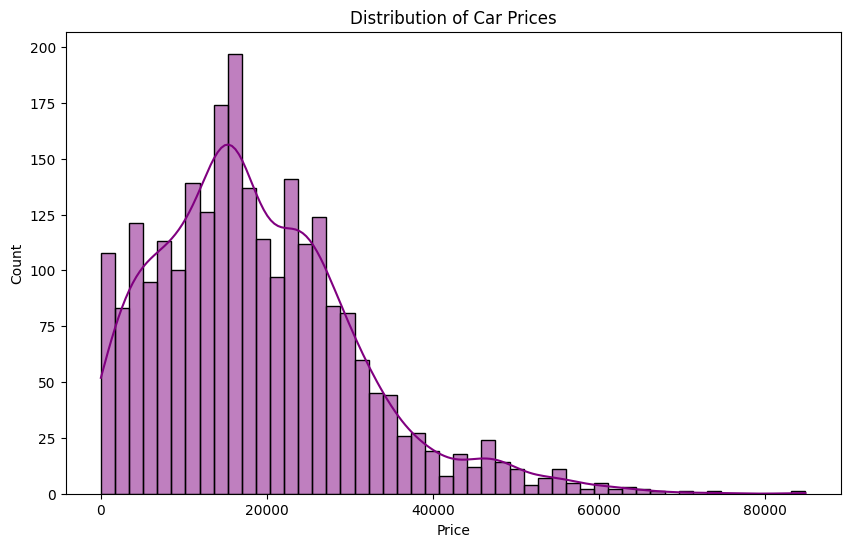

In [6]:
#histogram of car price
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True, color='purple')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

/tmp/ipython-input-1140713900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='brand', y='price', data=df_top, palette='magma')


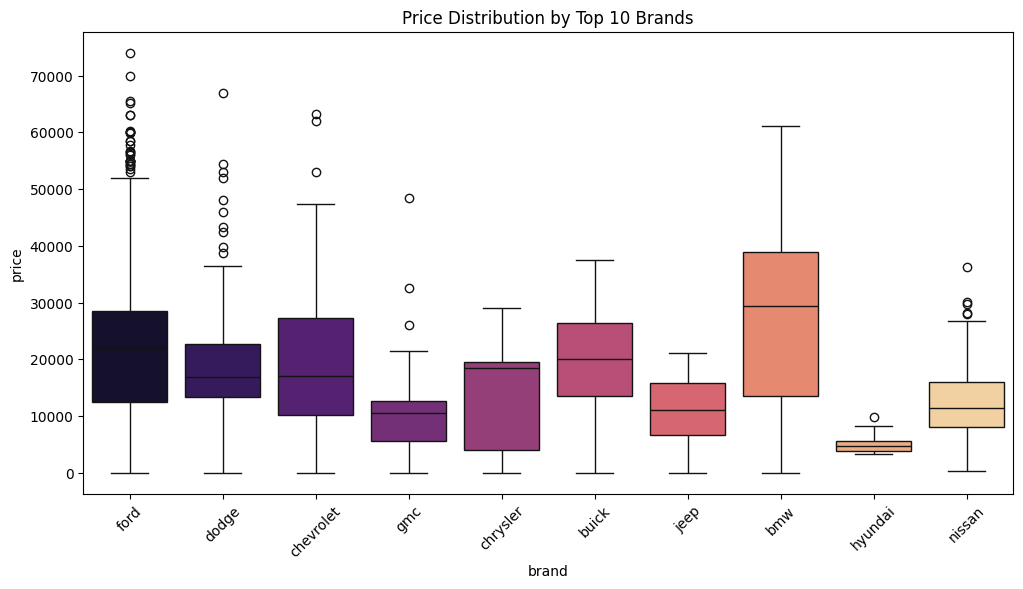

In [8]:
#Box plor of price by brand
top_brands = df['brand'].value_counts().nlargest(10).index
df_top = df[df['brand'].isin(top_brands)]

plt.figure(figsize=(12,6))
sns.boxplot(x='brand', y='price', data=df_top, palette='magma')
plt.xticks(rotation=45)
plt.title("Price Distribution by Top 10 Brands")
plt.show()


In [18]:
#Interactive Scatter Plot
import plotly.express as px

fig = px.scatter(df, x="mileage", y="price",
                 color="condition",
                 hover_data=["brand","model","year","country"],
                 title="Price vs Mileage by Condition")
fig.show()

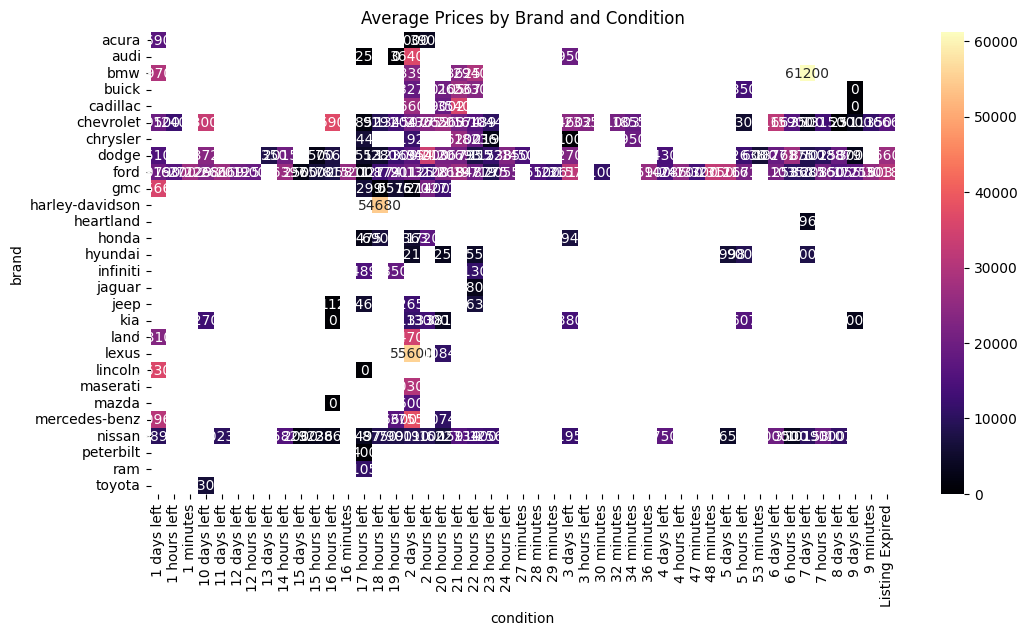

In [20]:
#Optional heatmap of average prices by brand and condition
pivot = df.pivot_table(values='price', index='brand', columns='condition', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap='magma')
plt.title("Average Prices by Brand and Condition")
plt.show()